# Exercise 1

<>:40: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:41: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:40: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:41: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_15347/1726963848.py:40: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  ax2.plot(n_range, actual_error, label='Actual Error $|\epsilon_n|$', color='green')
/tmp/ipykernel_15347/1726963848.py:41: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will no

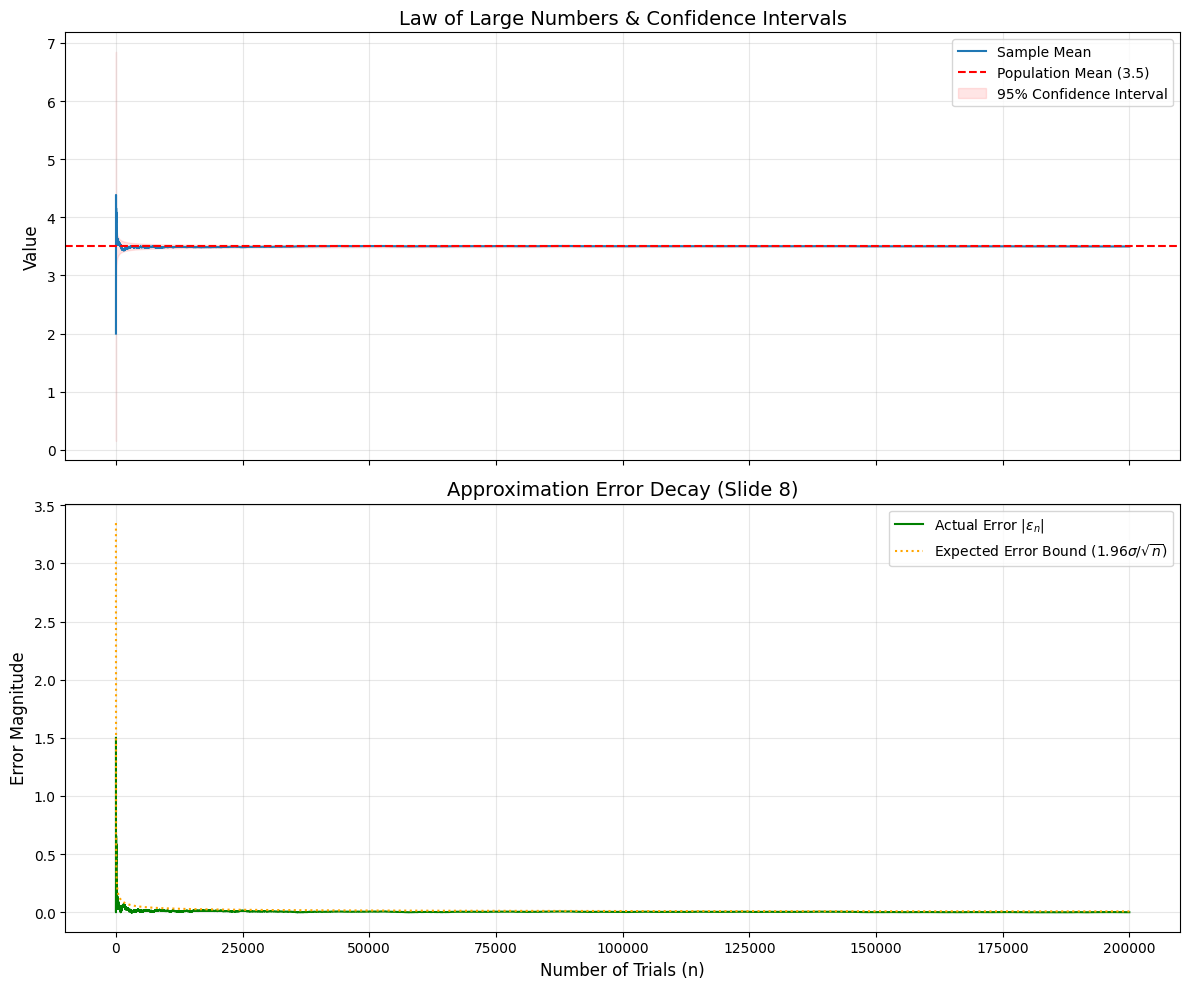

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuration
n_trials = 200000
expected_value = 3.5
# Theoretical standard deviation for a die roll: sqrt((6^2 - 1) / 12)
sigma = np.sqrt(35/12) 

# 2. Simulation
rolls = np.random.randint(1, 7, size=n_trials)
n_range = np.arange(1, n_trials + 1)
running_averages = np.cumsum(rolls) / n_range

# 3. Calculate 95% Confidence Interval (Slide 10)
# Formula: 1.96 * (sigma / sqrt(n))
ci_bound = 1.96 * (sigma / np.sqrt(n_range))

# 4. Create the Visualization with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Subplot 1: Convergence with Confidence Interval ---
ax1.plot(n_range, running_averages, label='Sample Mean', color='#1f77b4')
ax1.axhline(y=expected_value, color='red', linestyle='--', label='Population Mean (3.5)')

# Shading the Confidence Interval region (Slide 10)
ax1.fill_between(n_range, 
                 expected_value - ci_bound, 
                 expected_value + ci_bound, 
                 color='red', alpha=0.1, label='95% Confidence Interval')

ax1.set_title('Law of Large Numbers & Confidence Intervals', fontsize=14)
ax1.set_ylabel('Value', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Approximation Error Magnitude ---
actual_error = np.abs(running_averages - expected_value)

ax2.plot(n_range, actual_error, label='Actual Error $|\epsilon_n|$', color='green')
ax2.plot(n_range, ci_bound, label='Expected Error Bound ($1.96\sigma/\sqrt{n}$)', color='orange', linestyle=':')

ax2.set_title('Approximation Error Decay (Slide 8)', fontsize=14)
ax2.set_xlabel('Number of Trials (n)', fontsize=12)
ax2.set_ylabel('Error Magnitude', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exercise 2

<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_15347/4198373166.py:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.plot(estimates, label='Monte Carlo Estimate of $\pi$', color='#1f77b4')
/tmp/ipykernel_15347/4198373166.py:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work i

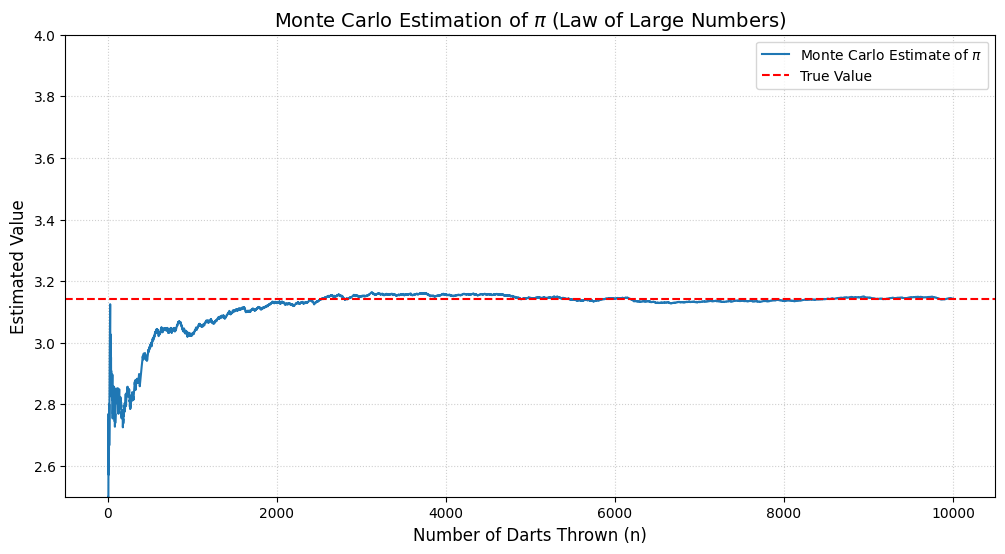

In [17]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000
n = 0
# Generating points in a 2x2 square (from 0 to 2)
sample1 = np.random.uniform(0, 2, N)
sample2 = np.random.uniform(0, 2, N)

estimates = []

for i in range(N):
    # Check if point (sample1, sample2) is inside circle centered at (1,1) with radius 1
    if (np.sqrt((sample1[i]-1)**2 + (sample2[i]-1)**2) < 1):
        n += 1
    
    # Calculate the estimate of PI at THIS specific step i
    # Formula from Slide 4: pi approx 4 * (hits / trials_so_far)
    current_estimate = 4 * (n / (i + 1))
    estimates.append(current_estimate)

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot the running estimate
plt.plot(estimates, label='Monte Carlo Estimate of $\pi$', color='#1f77b4')

# Plot the theoretical value of PI (Slide 7: "The limit")
plt.axhline(y=np.pi, color='red', linestyle='--', label=f'True Value')

# Formatting
plt.title('Monte Carlo Estimation of $\pi$ (Law of Large Numbers)', fontsize=14)
plt.xlabel('Number of Darts Thrown (n)', fontsize=12)
plt.ylabel('Estimated Value', fontsize=12)
plt.ylim(2.5, 4.0) # Adjusted to see the convergence around 3.14
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()